# 統合消費電流測定解析

nrf_power_test_all.ino で全フェーズを一括測定したデータを解析する。

**フェーズ構成**:
- フェーズ1: 待機電力 (delay/WFI/WFE × 各5回 × 10秒)
- フェーズ2: WiFiスキャン (1/3/5/10秒 × 各10回)
- フェーズ3: カメラ (60秒録画 × 5回)
- フェーズ4: SD書き込み (B:一括 × 10回, C:毎秒60秒 × 3回)

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

CSV_FILE = 'dist/current_log_all.csv'

In [100]:
# ============================================================
# データ読み込み
# ============================================================
df = pd.read_csv(CSV_FILE)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.reset_index(drop=True)
df['elapsed_s'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()

print(f'データ件数: {len(df)}')
print(f'時間範囲: {df["Timestamp"].iloc[0]} ~ {df["Timestamp"].iloc[-1]}')
print(f'全体時間: {df["elapsed_s"].iloc[-1]/60:.1f} 分')

データ件数: 33914
時間範囲: 2026-03-19 13:03:01.176473 ~ 2026-03-19 13:32:28.138185
全体時間: 29.4 分


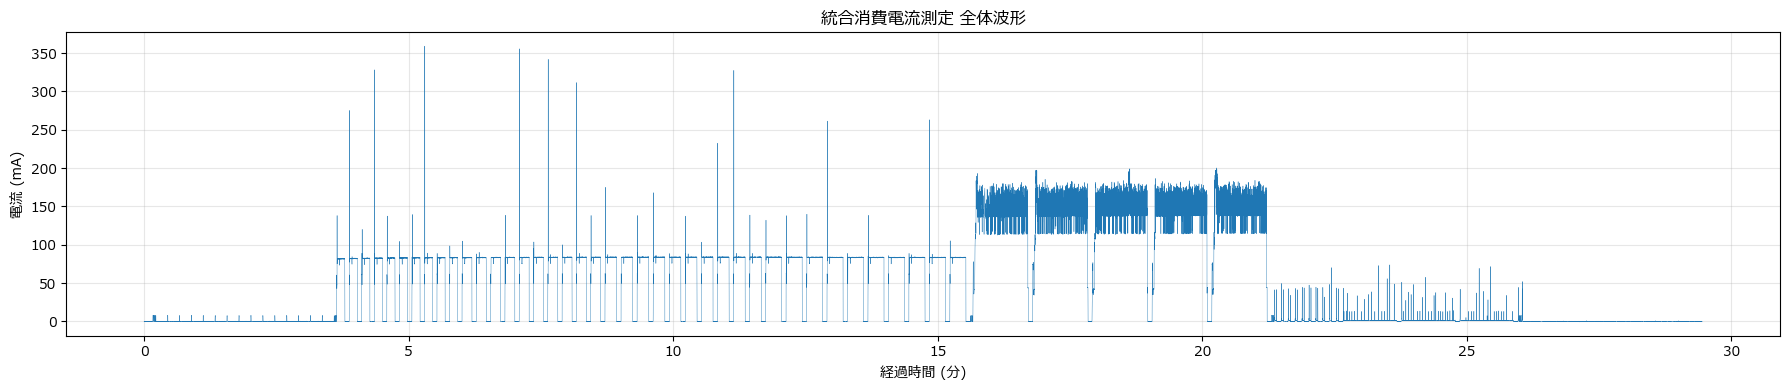

In [101]:
# ============================================================
# 全体の電流波形
# ============================================================
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(df['elapsed_s']/60, df['Current (mA)'], linewidth=0.3)
ax.set_xlabel('経過時間 (分)')
ax.set_ylabel('電流 (mA)')
ax.set_title('統合消費電流測定 全体波形')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [102]:
# ============================================================
# フェーズ区間の検出 (3連CPUマーカーでフェーズ区切り)
# ============================================================
current = df['Current (mA)'].values
timestamps = df['elapsed_s'].values

# 5mA以上のスパイクを検出
is_spike = current > 5.0
transitions = np.diff(is_spike.astype(int))
spike_starts = np.where(transitions == 1)[0] + 1
spike_times = timestamps[spike_starts]

# 3連スパイク (フェーズマーカー) を検出
# 3連マーカーは 500ms ON + 500ms OFF × 3 = 約3秒以内に3スパイク
phase_marker_times = []
i = 0
while i < len(spike_times) - 2:
    if spike_times[i+2] - spike_times[i] < 4.0:
        phase_marker_times.append(spike_times[i])
        i += 3
    else:
        i += 1

print(f'フェーズマーカー: {len(phase_marker_times)}個')
for i, t in enumerate(phase_marker_times):
    print(f'  [{i+1}] t={t:.1f}s ({t/60:.1f}分)')

フェーズマーカー: 9個
  [1] t=10.0s (0.2分)
  [2] t=215.5s (3.6分)
  [3] t=937.3s (15.6分)
  [4] t=1278.7s (21.3分)
  [5] t=1282.0s (21.4分)
  [6] t=1360.2s (22.7分)
  [7] t=1523.1s (25.4分)
  [8] t=1558.7s (26.0分)
  [9] t=1561.4s (26.0分)


In [103]:
# ============================================================
# フェーズ1: 待機電力解析
# ============================================================
# フェーズ1はマーカー[0]後 ～ マーカー[1]前
# 各サイクル開始時に1連CPUマーカー

if len(phase_marker_times) >= 2:
    p1_start = phase_marker_times[0] + 4  # 3連マーカー後
    p1_end = phase_marker_times[1]
    
    p1_data = df[(df['elapsed_s'] >= p1_start) & (df['elapsed_s'] < p1_end)]
    p1_spikes = spike_times[(spike_times >= p1_start) & (spike_times < p1_end)]
    
    print(f'フェーズ1区間: {p1_start:.0f}~{p1_end:.0f}秒')
    print(f'サイクルマーカー: {len(p1_spikes)}個 (期待値: 15)')
    
    # マーカー後の10秒区間の電流
    wait_results = []
    patterns = ['delay()', '__WFI()', '__WFE()']
    for i, t in enumerate(p1_spikes):
        t_start = t + 1  # マーカー後1秒
        t_end = t_start + 10
        seg = df[(df['elapsed_s'] >= t_start) & (df['elapsed_s'] < t_end)]
        if len(seg) > 0:
            pidx = i // 5
            pattern = patterns[pidx] if pidx < len(patterns) else '?'
            wait_results.append({
                'pattern': pattern,
                'rep': i % 5 + 1,
                'mean_mA': seg['Current (mA)'].mean(),
            })
    
    df_wait = pd.DataFrame(wait_results)
    print('\n--- 待機電力パターン別 ---')
    summary_wait = df_wait.groupby('pattern')['mean_mA'].agg(['mean', 'std']).reset_index()
    summary_wait.columns = ['パターン', '平均電流(mA)', '標準偏差(mA)']
    print(summary_wait.to_string(index=False))
else:
    print('フェーズマーカー不足')

フェーズ1区間: 14~216秒
サイクルマーカー: 14個 (期待値: 15)

--- 待機電力パターン別 ---
   パターン  平均電流(mA)  標準偏差(mA)
__WFE()  0.056500  0.009423
__WFI()  0.049888  0.006901
delay() -0.050447  0.066505


In [104]:
# ============================================================
# フェーズ2: WiFiスキャン解析
# ============================================================
# 30mA以上, 1秒以上のON区間を検出 (フェーズ2区間内のみ)
if len(phase_marker_times) >= 3:
    p2_start = phase_marker_times[1] + 4  # フェーズ2マーカー後
    p2_end = phase_marker_times[2]
else:
    p2_start = 200
    p2_end = 950

p2_mask = (timestamps >= p2_start) & (timestamps < p2_end)
p2_current = current.copy()
p2_current[~p2_mask] = 0  # フェーズ2外はゼロに

is_on = p2_current > 30
transitions_on = np.diff(is_on.astype(int))
on_starts = np.where(transitions_on == 1)[0] + 1
on_ends = np.where(transitions_on == -1)[0] + 1
if is_on[0]: on_starts = np.insert(on_starts, 0, 0)
if is_on[-1]: on_ends = np.append(on_ends, len(is_on))
n_cycles = min(len(on_starts), len(on_ends))

wifi_intervals = []
for i in range(n_cycles):
    s, e = on_starts[i], on_ends[i]
    dur = timestamps[min(e, len(timestamps)-1)] - timestamps[s]
    if dur >= 1.0:
        wifi_intervals.append((s, e))

print(f'フェーズ2区間: {p2_start:.0f}~{p2_end:.0f}秒')
print(f'WiFi ON区間: {len(wifi_intervals)}個 (期待値: 40)')

# ベースライン (フェーズ2内のOFF区間のみ)
p2_on_idx = set()
for s, e in wifi_intervals:
    p2_on_idx.update(range(s, e))
p2_all_idx = set(np.where(p2_mask)[0])
p2_off_idx = p2_all_idx - p2_on_idx
p2_off_mask = df.index.isin(p2_off_idx)
wifi_baseline = df.loc[p2_off_mask, 'Current (mA)'].mean()
print(f'WiFiベースライン電流 (フェーズ2 OFF区間): {wifi_baseline:.2f} mA')

# WiFiパターン別集計 (ベースライン差し引き)
SCAN_PATTERNS = [1000, 3000, 5000, 10000]
wifi_results = []
for i, (s, e) in enumerate(wifi_intervals):
    seg = current[s:e]
    dur = timestamps[min(e, len(timestamps)-1)] - timestamps[s]
    pidx = i // 10
    wifi_results.append({
        'scan_ms': SCAN_PATTERNS[pidx] if pidx < len(SCAN_PATTERNS) else -1,
        'rep': i % 10 + 1,
        'duration_s': dur,
        'mean_mA': seg.mean() - wifi_baseline,
        'peak_mA': seg.max() - wifi_baseline,
    })

df_wifi = pd.DataFrame(wifi_results)
summary_wifi = df_wifi.groupby('scan_ms').agg(
    回数=('mean_mA', 'count'),
    ON区間秒=('duration_s', 'mean'),
    平均電流=('mean_mA', 'mean'),
    標準偏差=('mean_mA', 'std'),
    ピーク=('peak_mA', 'max'),
).reset_index()
summary_wifi.columns = ['スキャン(ms)', '回数', 'ON区間(秒)', '平均電流(mA)', '標準偏差(mA)', 'ピーク(mA)']

print('\n=== WiFiスキャン パターン別集計 (ベースライン差し引き) ===')
print(summary_wifi.to_string(index=False))

フェーズ2区間: 220~937秒
WiFi ON区間: 40個 (期待値: 40)
WiFiベースライン電流 (フェーズ2 OFF区間): 0.05 mA

=== WiFiスキャン パターン別集計 (ベースライン差し引き) ===
 スキャン(ms)  回数   ON区間(秒)  平均電流(mA)  標準偏差(mA)    ピーク(mA)
     1000  10  9.069089 81.986510  0.685128 358.950474
     3000  10 11.191779 82.793972  0.566413 355.450474
     5000  10 13.192496 83.032696  0.317902 327.350474
    10000  10 18.181790 83.011004  0.230151 262.950474


In [105]:
# ============================================================
# フェーズ3: カメラ解析
# ============================================================
if len(phase_marker_times) >= 4:
    p3_start = phase_marker_times[2] + 4
    p3_end = phase_marker_times[3]
else:
    p3_start = 930
    p3_end = 1280

p3_mask = (timestamps >= p3_start) & (timestamps < p3_end)
p3_current = current.copy()
p3_current[~p3_mask] = 0

is_cam_on = p3_current > 30
cam_trans = np.diff(is_cam_on.astype(int))
cam_on_starts = np.where(cam_trans == 1)[0] + 1
cam_on_ends = np.where(cam_trans == -1)[0] + 1
if is_cam_on[0]: cam_on_starts = np.insert(cam_on_starts, 0, 0)
if is_cam_on[-1]: cam_on_ends = np.append(cam_on_ends, len(is_cam_on))
cam_n = min(len(cam_on_starts), len(cam_on_ends))

camera_intervals = []
for i in range(cam_n):
    s, e = cam_on_starts[i], cam_on_ends[i]
    dur = timestamps[min(e, len(timestamps)-1)] - timestamps[s]
    if dur >= 1.0:
        camera_intervals.append((s, e))

print(f'フェーズ3区間: {p3_start:.0f}~{p3_end:.0f}秒')
print(f'カメラ ON区間: {len(camera_intervals)}個 (期待値: 5)')

# ベースライン (フェーズ3内のOFF区間)
p3_on_idx = set()
for s, e in camera_intervals:
    p3_on_idx.update(range(s, e))
p3_all_idx = set(np.where(p3_mask)[0])
p3_off_idx = p3_all_idx - p3_on_idx
p3_off_mask = df.index.isin(p3_off_idx)
cam_baseline = df.loc[p3_off_mask, 'Current (mA)'].mean()
print(f'カメラベースライン電流 (フェーズ3 OFF区間): {cam_baseline:.2f} mA')

camera_results = []
for i, (s, e) in enumerate(camera_intervals):
    seg = current[s:e]
    dur = timestamps[min(e, len(timestamps)-1)] - timestamps[s]
    camera_results.append({
        'rep': i + 1,
        'duration_s': dur,
        'mean_mA': seg.mean() - cam_baseline,
        'peak_mA': seg.max() - cam_baseline,
    })

df_camera = pd.DataFrame(camera_results)
print('\n=== カメラ録画 (ベースライン差し引き) ===')
print(df_camera.to_string(index=False))
print(f'\n平均電流: {df_camera["mean_mA"].mean():.1f} mA')
print(f'ピーク電流: {df_camera["peak_mA"].max():.1f} mA')

フェーズ3区間: 941~1279秒
カメラ ON区間: 5個 (期待値: 5)
カメラベースライン電流 (フェーズ3 OFF区間): 0.15 mA

=== カメラ録画 (ベースライン差し引き) ===
 rep  duration_s    mean_mA    peak_mA
   1   61.229253 142.819267 192.949107
   2   62.687391 140.781834 197.249107
   3   62.685807 141.962973 198.949107
   4   62.712900 140.762987 186.349107
   5   62.662383 142.033837 200.049107

平均電流: 141.7 mA
ピーク電流: 200.0 mA


In [106]:
# ============================================================
# フェーズ4: SD書き込み解析
# ============================================================
# カメラ終了後、電流が0に落ちてから再び立ち上がる地点をフェーズ4開始とする
if camera_intervals:
    last_cam_end = timestamps[camera_intervals[-1][1]]
    # カメラ終了後にベースラインに落ちてから、次に3mA超えた地点を探す
    post_cam = df[(df['elapsed_s'] > last_cam_end + 2) & (df['Current (mA)'] > 3)]
    if len(post_cam) > 0:
        p4_start = post_cam['elapsed_s'].iloc[0] + 3  # 3連マーカーを飛ばす
    else:
        p4_start = last_cam_end + 5
else:
    p4_start = p3_end + 5

# 電流がゼロに落ちる直前まで
p4_candidates = df[(df['elapsed_s'] > p4_start + 60) & (df['Current (mA)'] > 3)]
if len(p4_candidates) > 0:
    p4_end = p4_candidates['elapsed_s'].max() + 5
else:
    p4_end = timestamps[-1]

p4_data = df[(df['elapsed_s'] >= p4_start) & (df['elapsed_s'] < p4_end)]
print(f'フェーズ4区間: {p4_start:.0f}~{p4_end:.0f}秒 ({(p4_end-p4_start)/60:.1f}分)')
print(f'データ件数: {len(p4_data)}')

# パターンBとCの境界を推定
# パターンB後にベースラインが~1.2mAに持ち上がる地点を検出
# 5秒ウィンドウでベースライン(<5mA)の平均を見て、1.0mA超えが続く地点
window = 5
for offset in range(0, 200, window):
    t0 = p4_start + offset
    t1 = t0 + window
    seg = df[(df['elapsed_s'] >= t0) & (df['elapsed_s'] < t1)]
    low = seg[seg['Current (mA)'] < 5]
    if len(low) > 0 and low['Current (mA)'].mean() > 1.0:
        pb_end = t0
        break
else:
    pb_end = p4_start + 76

pb_data = df[(df['elapsed_s'] >= p4_start) & (df['elapsed_s'] < pb_end)]
pc_data = df[(df['elapsed_s'] >= pb_end) & (df['elapsed_s'] < p4_end)]

print(f'\nパターンB区間: {p4_start:.0f}~{pb_end:.0f}秒 ({(pb_end-p4_start):.0f}秒)')
print(f'  全体平均電流: {pb_data["Current (mA)"].mean():.2f} mA')
print(f'  最大電流: {pb_data["Current (mA)"].max():.1f} mA')

# パターンBのベースライン (OFF区間のみ)
pb_low = pb_data[pb_data['Current (mA)'] < 3]
pb_baseline = pb_low['Current (mA)'].mean() if len(pb_low) > 0 else 0
print(f'  ベースライン (SD OFF): {pb_baseline:.2f} mA')

# パターンBの書き込みスパイク平均
pb_high = pb_data[pb_data['Current (mA)'] > 10]
pb_spike_mean = pb_high['Current (mA)'].mean() if len(pb_high) > 0 else 0
print(f'  書き込みスパイク平均: {pb_spike_mean:.1f} mA')

print(f'\nパターンC区間: {pb_end:.0f}~{p4_end:.0f}秒 ({(p4_end-pb_end):.0f}秒)')
print(f'  全体平均電流: {pc_data["Current (mA)"].mean():.2f} mA')
print(f'  最大電流: {pc_data["Current (mA)"].max():.1f} mA')

# パターンCのベースライン (SD ON アイドル)
pc_low = pc_data[pc_data['Current (mA)'] < 5]
pc_baseline = pc_low['Current (mA)'].mean() if len(pc_low) > 0 else 0
print(f'  ベースライン (SD ON アイドル): {pc_baseline:.2f} mA')

# パターンCを60秒ON + 5秒OFFで分割
print('\n--- パターンC 各サイクル ---')
for i in range(3):
    t0 = pb_end + i * 65
    t1 = t0 + 60
    seg = df[(df['elapsed_s'] >= t0) & (df['elapsed_s'] < t1)]
    off_seg = df[(df['elapsed_s'] >= t1) & (df['elapsed_s'] < t1 + 5)]
    if len(seg) > 0:
        seg_low = seg[seg['Current (mA)'] < 5]
        seg_baseline = seg_low['Current (mA)'].mean() if len(seg_low) > 0 else 0
        print(f'  C-{i+1} ON (60秒): mean={seg["Current (mA)"].mean():.2f}mA, baseline={seg_baseline:.2f}mA, max={seg["Current (mA)"].max():.1f}mA')
    if len(off_seg) > 0:
        print(f'  C-{i+1} OFF (5秒):  mean={off_seg["Current (mA)"].mean():.2f}mA')

print(f'\n=== SD方式比較 ===')
print(f'パターンB (1分1回ON) サイクル平均: {pb_data["Current (mA)"].mean():.2f} mA')
print(f'パターンC (常時ON)   サイクル平均: {pc_data["Current (mA)"].mean():.2f} mA')
print(f'SD ON アイドル電流: {pc_baseline:.2f} mA')

フェーズ4区間: 1282~1569秒 (4.8分)
データ件数: 5591

パターンB区間: 1282~1362秒 (80秒)
  全体平均電流: 1.82 mA
  最大電流: 70.2 mA
  ベースライン (SD OFF): 0.39 mA
  書き込みスパイク平均: 36.5 mA

パターンC区間: 1362~1569秒 (207秒)
  全体平均電流: 1.61 mA
  最大電流: 73.8 mA
  ベースライン (SD ON アイドル): 1.11 mA

--- パターンC 各サイクル ---
  C-1 ON (60秒): mean=1.66mA, baseline=1.22mA, max=73.8mA
  C-1 OFF (5秒):  mean=1.42mA
  C-2 ON (60秒): mean=1.66mA, baseline=1.23mA, max=57.7mA
  C-2 OFF (5秒):  mean=0.01mA
  C-3 ON (60秒): mean=1.63mA, baseline=1.23mA, max=71.6mA
  C-3 OFF (5秒):  mean=0.39mA

=== SD方式比較 ===
パターンB (1分1回ON) サイクル平均: 1.82 mA
パターンC (常時ON)   サイクル平均: 1.61 mA
SD ON アイドル電流: 1.11 mA


In [107]:
# ============================================================
# SD方式の正確な比較 (電流積分ベース)
# ============================================================

dt = df['elapsed_s'].diff().median()  # サンプリング間隔 (秒)

# --- パターンB: 区間全体を積分して10サイクルで割る ---
pb_current = pb_data['Current (mA)'].values
pb_total_charge = pb_current.sum() * dt  # 全区間の電流累積 (mA・秒)
pb_total_time = pb_data['elapsed_s'].iloc[-1] - pb_data['elapsed_s'].iloc[0]
pb_num_cycles = 10
pb_charge_per_cycle = pb_total_charge / pb_num_cycles  # 1サイクルあたりの累積
pb_per_min = pb_charge_per_cycle / 60.0  # 1分あたりの平均電流

print('--- パターンB (1分1回ON方式) ---')
print(f'  区間: {pb_total_time:.1f}秒, {pb_num_cycles}サイクル')
print(f'  全区間の電流累積: {pb_total_charge:.1f} mA・秒')
print(f'  1サイクルあたり: {pb_charge_per_cycle:.2f} mA・秒')
print(f'  1分あたり平均電流: {pb_per_min:.3f} mA')

# --- パターンC: 各60秒ON区間を積分 ---
print(f'\n--- パターンC (常時ON方式) ---')
pc_cycles = []
for i in range(3):
    t0 = pb_end + i * 65
    t1 = t0 + 60
    seg = df[(df['elapsed_s'] >= t0) & (df['elapsed_s'] < t1)]
    if len(seg) > 0:
        dur = seg['elapsed_s'].iloc[-1] - seg['elapsed_s'].iloc[0]
        charge = seg['Current (mA)'].sum() * dt
        mean = charge / dur if dur > 0 else 0
        pc_cycles.append({'dur_s': dur, 'charge_mAs': charge, 'mean_mA': mean})
        print(f'  C-{i+1}: dur={dur:.1f}s, 累積={charge:.1f} mA・s, 平均={mean:.3f} mA')

if pc_cycles:
    df_pc = pd.DataFrame(pc_cycles)
    avg_charge_c = df_pc['charge_mAs'].mean()
    avg_per_min_c = avg_charge_c / 60.0

    print(f'\n  1サイクル平均累積: {avg_charge_c:.1f} mA・秒')
    print(f'  1分あたり平均電流: {avg_per_min_c:.3f} mA')

# --- 比較 ---
if pc_cycles:
    diff = avg_per_min_c - pb_per_min
    print(f'\n{"="*50}')
    print(f'SD方式比較 (1分あたりの平均電流)')
    print(f'{"="*50}')
    print(f'パターンB (1分1回ON): {pb_per_min:.3f} mA')
    print(f'パターンC (常時ON):   {avg_per_min_c:.3f} mA')
    print(f'差: {diff:.3f} mA')
    print(f'\n24時間運用での差: {diff * 24:.2f} mAh')
    print(f'500mAhバッテリーに対する割合: {diff * 24 / 500 * 100:.2f}%')

--- パターンB (1分1回ON方式) ---
  区間: 80.0秒, 10サイクル
  全区間の電流累積: 142.1 mA・秒
  1サイクルあたり: 14.21 mA・秒
  1分あたり平均電流: 0.237 mA

--- パターンC (常時ON方式) ---
  C-1: dur=59.9s, 累積=98.5 mA・s, 平均=1.643 mA
  C-2: dur=59.9s, 累積=99.4 mA・s, 平均=1.658 mA
  C-3: dur=59.9s, 累積=97.8 mA・s, 平均=1.632 mA

  1サイクル平均累積: 98.6 mA・秒
  1分あたり平均電流: 1.643 mA

SD方式比較 (1分あたりの平均電流)
パターンB (1分1回ON): 0.237 mA
パターンC (常時ON):   1.643 mA
差: 1.406 mA

24時間運用での差: 33.74 mAh
500mAhバッテリーに対する割合: 6.75%


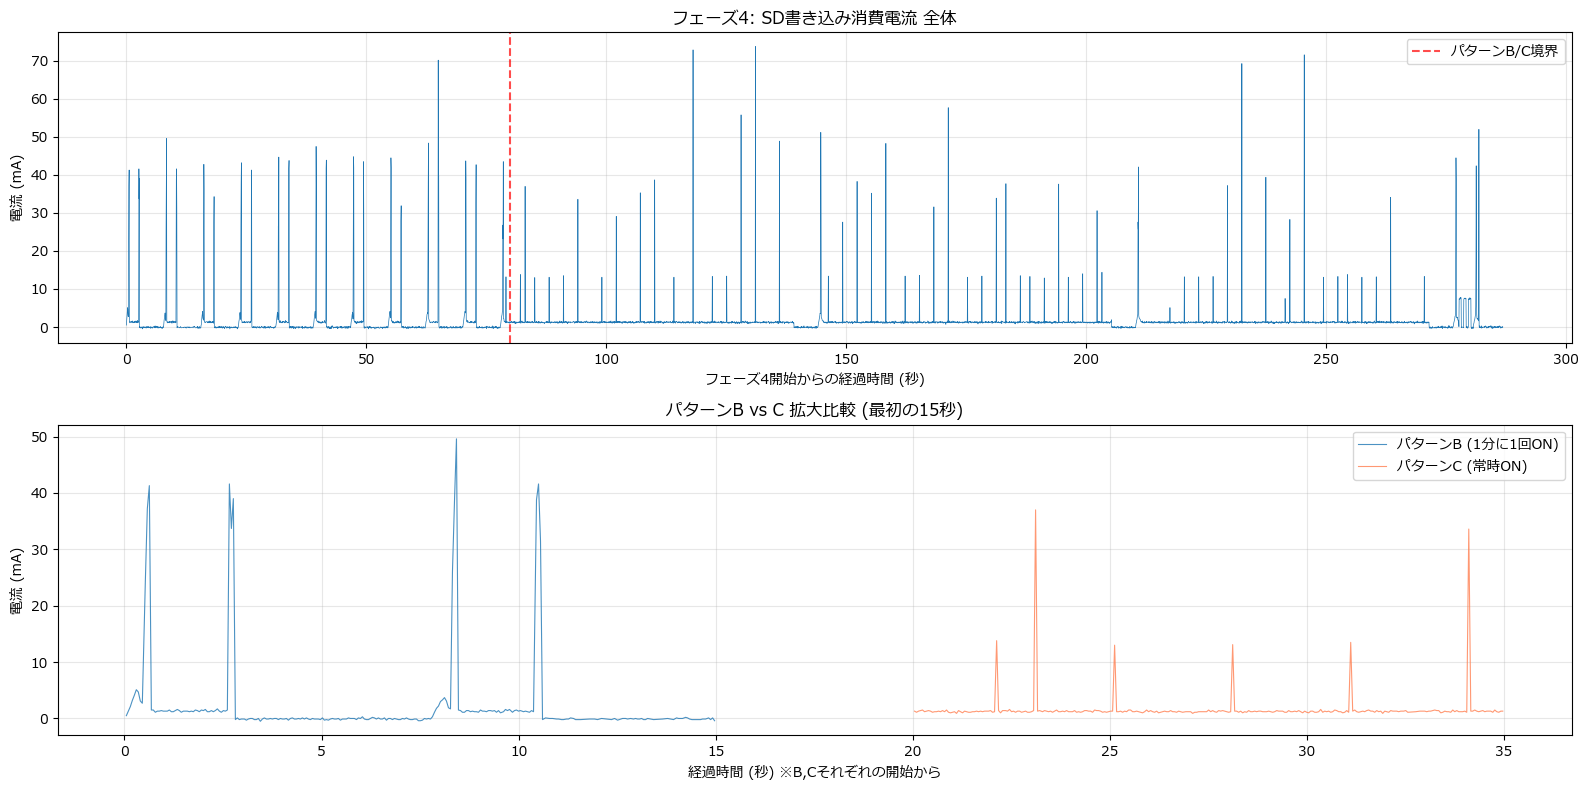

In [108]:
# ============================================================
# フェーズ4: SD区間の電流波形
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# 上段: フェーズ4全体
ax = axes[0]
ax.plot(p4_data['elapsed_s'] - p4_start, p4_data['Current (mA)'], linewidth=0.5)
ax.axvline(x=pb_end - p4_start, color='red', linestyle='--', alpha=0.7, label='パターンB/C境界')
ax.set_xlabel('フェーズ4開始からの経過時間 (秒)')
ax.set_ylabel('電流 (mA)')
ax.set_title('フェーズ4: SD書き込み消費電流 全体')
ax.legend()
ax.grid(True, alpha=0.3)

# 下段: パターンB/Cの拡大比較 (それぞれ最初の15秒)
ax = axes[1]

# パターンBの最初の15秒
pb_zoom = df[(df['elapsed_s'] >= p4_start) & (df['elapsed_s'] < p4_start + 15)]
ax.plot(pb_zoom['elapsed_s'] - p4_start, pb_zoom['Current (mA)'],
        linewidth=0.8, label='パターンB (1分に1回ON)', alpha=0.8)

# パターンCの最初の15秒
pc_zoom = df[(df['elapsed_s'] >= pb_end) & (df['elapsed_s'] < pb_end + 15)]
ax.plot(pc_zoom['elapsed_s'] - pb_end + 20, pc_zoom['Current (mA)'],  # 20秒オフセットで並べる
        linewidth=0.8, label='パターンC (常時ON)', alpha=0.8, color='coral')

ax.set_xlabel('経過時間 (秒) ※B,Cそれぞれの開始から')
ax.set_ylabel('電流 (mA)')
ax.set_title('パターンB vs C 拡大比較 (最初の15秒)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [109]:
# ============================================================
# サマリーテーブル
# ============================================================
print('=' * 60)
print('統合消費電流測定 サマリー')
print('=' * 60)
print(f'WiFiベースライン (フェーズ2 OFF区間): {wifi_baseline:.2f} mA')
print(f'カメラベースライン (フェーズ3 OFF区間): {cam_baseline:.2f} mA')
print()

print('--- 待機電力 ---')
print(summary_wait.to_string(index=False))
print()

print('--- WiFiスキャン (ベースライン差し引き) ---')
print(summary_wifi.to_string(index=False))
print()

print('--- カメラ (ベースライン差し引き) ---')
print(f'平均電流: {df_camera["mean_mA"].mean():.1f} mA')
print(f'ピーク電流: {df_camera["peak_mA"].max():.1f} mA')
print(f'ON区間平均: {df_camera["duration_s"].mean():.1f} 秒')
print()

print('--- SD書き込み ---')
print(f'フェーズ4区間の平均電流: {p4_data["Current (mA)"].mean():.2f} mA')
print(f'SD ON区間数: {len(sd_valid)}')

統合消費電流測定 サマリー
WiFiベースライン (フェーズ2 OFF区間): 0.05 mA
カメラベースライン (フェーズ3 OFF区間): 0.15 mA

--- 待機電力 ---
   パターン  平均電流(mA)  標準偏差(mA)
__WFE()  0.056500  0.009423
__WFI()  0.049888  0.006901
delay() -0.050447  0.066505

--- WiFiスキャン (ベースライン差し引き) ---
 スキャン(ms)  回数   ON区間(秒)  平均電流(mA)  標準偏差(mA)    ピーク(mA)
     1000  10  9.069089 81.986510  0.685128 358.950474
     3000  10 11.191779 82.793972  0.566413 355.450474
     5000  10 13.192496 83.032696  0.317902 327.350474
    10000  10 18.181790 83.011004  0.230151 262.950474

--- カメラ (ベースライン差し引き) ---
平均電流: 141.7 mA
ピーク電流: 200.0 mA
ON区間平均: 62.4 秒

--- SD書き込み ---
フェーズ4区間の平均電流: 1.67 mA
SD ON区間数: 27


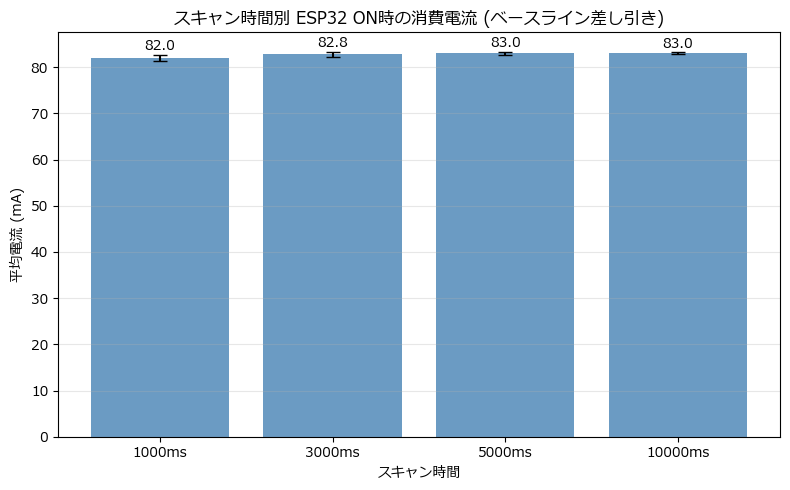

In [110]:
# ============================================================
# WiFiスキャン時間別 平均電流グラフ
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

x = summary_wifi['スキャン(ms)'].values
y = summary_wifi['平均電流(mA)'].values
yerr = summary_wifi['標準偏差(mA)'].values

ax.bar(range(len(x)), y, yerr=yerr, capsize=5, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(x)))
ax.set_xticklabels([f'{int(v)}ms' for v in x])
ax.set_xlabel('スキャン時間')
ax.set_ylabel('平均電流 (mA)')
ax.set_title('スキャン時間別 ESP32 ON時の消費電流 (ベースライン差し引き)')
ax.grid(True, alpha=0.3, axis='y')

for i, (v, e) in enumerate(zip(y, yerr)):
    ax.text(i, v + e + 1, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()